# Passos Mágicos: análise exploratória

Aqui respondemos às perguntas de negócio do desafio com a base PEDE de 2022 a 2024 tratada no notebook `01_limpeza`. Analisamos os alunos da fase 0 (ALFA) à fase 7. Os universitários (fases 8 e 9) seguem outro processo de avaliação e não têm INDE em 2023 e 2024, como vimos na limpeza.

Olhamos os dados de duas formas. O retrato anual considera todos os alunos de cada ano e mostra como está a base. O painel acompanha o mesmo aluno em anos seguidos, cruzado pelo `ra`, e mostra se o aluno melhorou. Para falar de evolução usamos o painel, porque a composição da base muda muito de um ano para o outro.

A pergunta 9 (modelo preditivo) fica no notebook `03_modelo_preditivo`.

## 1. Importação das bibliotecas

In [1]:
%pip install "pandas>=2.2" numpy matplotlib scikit-learn -q

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURAS = RAIZ / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

AZUL, LARANJA, VERDE, CINZA = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"
NIVEIS = ["Em fase", "Moderada", "Severa"]
CORES_NIVEL = ["#86b6ef", "#2a78d6", "#104281"]
ORDEM_PEDRA = ["Quartzo", "Ágata", "Ametista", "Topázio"]

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "axes.titleweight": "bold",
})

def salvar(fig, nome):
    fig.tight_layout()
    fig.savefig(FIGURAS / nome, dpi=150, bbox_inches="tight")
    plt.show()

## 2. Carregamento dos dados

In [3]:
df = pd.read_csv(RAIZ / "dados" / "tratados" / "pede_long.csv")
df["nivel_defasagem"] = pd.Categorical(df["nivel_defasagem"], categories=NIVEIS, ordered=True)
df["pedra"] = pd.Categorical(df["pedra"], categories=ORDEM_PEDRA, ordered=True)

alunos = df[~df["flag_universitario"]].copy()
print(f"Registros (fases 0 a 7): {len(alunos)}")
print(alunos.groupby("ano").size())

Registros (fases 0 a 7): 2865
ano
2022     860
2023     951
2024    1054
dtype: int64


In [4]:
# Painel: cada linha é um aluno no ano t com os valores do ano t+1 nas colunas *_t1
INDICADORES = ["inde", "ida", "ieg", "iaa", "ips", "ipp", "ipv"]
seguinte = alunos[["ra", "ano", "pedra", "fase", "defasagem"] + INDICADORES].assign(ano=lambda d: d["ano"] - 1)
painel = alunos.merge(seguinte, on=["ra", "ano"], suffixes=("", "_t1"))
print(f"Pares aluno/ano consecutivos: {len(painel)}")
print(painel.groupby("ano").size().rename(lambda a: f"{a} -> {a + 1}"))

Pares aluno/ano consecutivos: 1273
ano
2022 -> 2023    581
2023 -> 2024    692
dtype: int64


## 3. Adequação do nível (IAN)

*Qual é o perfil geral de defasagem dos alunos e como ele evolui?*

O IAN é a própria defasagem em três faixas (10 = em fase, 5 = moderada, 2,5 = severa), então a análise usa diretamente `nivel_defasagem`. Como a base tem um retrato por ano, a evolução só aparece de um ano para o outro.

In [5]:
perfil = pd.crosstab(alunos["ano"], alunos["nivel_defasagem"])
perfil_pct = pd.crosstab(alunos["ano"], alunos["nivel_defasagem"], normalize="index")
print(perfil)
print()
print((perfil_pct * 100).round(1))

nivel_defasagem  Em fase  Moderada  Severa
ano                                       
2022                 259       573      28
2023                 399       538      14
2024                 520       531       3

nivel_defasagem  Em fase  Moderada  Severa
ano                                       
2022                30.1      66.6     3.3
2023                42.0      56.6     1.5
2024                49.3      50.4     0.3


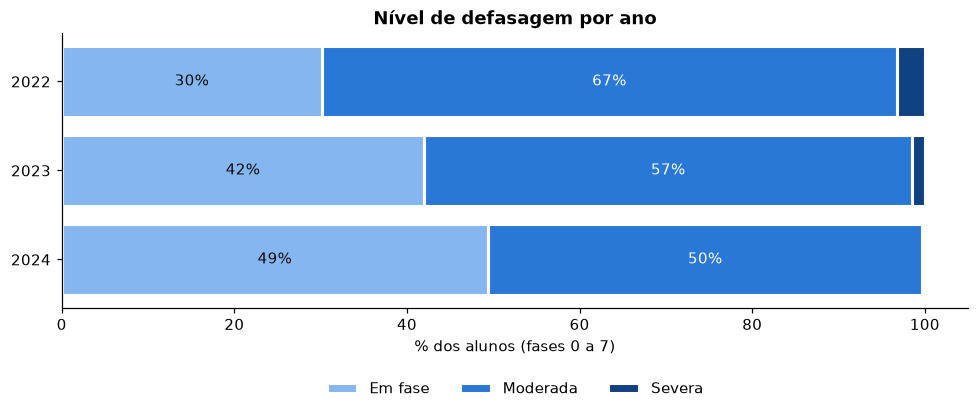

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
esquerda = np.zeros(len(perfil_pct))
for nivel, cor in zip(NIVEIS, CORES_NIVEL):
    valores = perfil_pct[nivel].values * 100
    ax.barh(perfil_pct.index.astype(str), valores, left=esquerda, color=cor, edgecolor="white", linewidth=2, label=nivel)
    for i, v in enumerate(valores):
        if v > 5:
            ax.text(esquerda[i] + v / 2, i, f"{v:.0f}%", ha="center", va="center",
                    color="white" if nivel != "Em fase" else "#0b0b0b", fontsize=10)
    esquerda += valores
ax.set_xlabel("% dos alunos (fases 0 a 7)")
ax.set_title("Nível de defasagem por ano")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.22), frameon=False)
ax.invert_yaxis()
ax.grid(False)
salvar(fig, "q1_defasagem_por_ano.png")

A proporção de alunos em fase subiu de 30% em 2022 para 42% em 2023 e 49% em 2024, e a defasagem severa praticamente desapareceu (de 3,3% para 0,3%). Ainda assim, cerca de metade dos alunos segue com defasagem moderada, de uma ou duas fases.

Como a base ganhou muitos alunos novos, verificamos se a melhora se sustenta quando olhamos apenas os mesmos alunos nos três anos:

In [7]:
anos_por_aluno = alunos.groupby("ra")["ano"].nunique()
mesmos_alunos = alunos[alunos["ra"].isin(anos_por_aluno[anos_por_aluno == 3].index)]
print(f"Alunos presentes nos 3 anos: {mesmos_alunos['ra'].nunique()}")
print((pd.crosstab(mesmos_alunos["ano"], mesmos_alunos["nivel_defasagem"], normalize="index") * 100).round(1))
print()
print("Alunos novos na fase ALFA, por ano:")
print((pd.crosstab(alunos.loc[alunos["fase"] == 0, "ano"], alunos.loc[alunos["fase"] == 0, "nivel_defasagem"], normalize="index") * 100).round(1))

Alunos presentes nos 3 anos: 441
nivel_defasagem  Em fase  Moderada  Severa
ano                                       
2022                34.0      64.6     1.4
2023                39.7      59.9     0.5
2024                63.0      36.5     0.5

Alunos novos na fase ALFA, por ano:
nivel_defasagem  Em fase  Moderada  Severa
ano                                       
2022                36.3      63.2     0.5
2023                49.4      50.2     0.4
2024                25.0      75.0     0.0


Entre os mesmos 441 alunos, a proporção em fase vai de 34% para 63%, então a melhora não se explica só pela entrada de novos alunos. Por outro lado, os alunos que chegam na fase ALFA já entram, em sua maioria, com defasagem moderada (75% em 2024). O programa recebe alunos atrasados e reduz esse atraso ao longo do tempo.

## 4. Desempenho acadêmico (IDA)

*O desempenho acadêmico médio está melhorando, estagnado ou caindo ao longo das fases e anos?*

In [8]:
print(alunos.groupby("ano")[["ida", "mat", "por", "ing"]].mean().round(2))
print()
ida_fase = alunos.pivot_table(index="fase", columns="ano", values="ida", aggfunc="mean")
print(ida_fase.round(2))

       ida   mat   por   ing
ano                         
2022  6.09  5.81  6.32  5.88
2023  6.66  6.41  6.82  6.20
2024  6.35  6.23  6.17  6.59

ano   2022  2023  2024
fase                  
0     7.14  7.42  7.32
1     6.46  6.81  6.79
2     5.41  6.74  6.25
3     5.14  5.75  5.35
4     6.05  6.00  5.88
5     5.87  5.90  6.45
6     6.69  6.81  7.23
7     5.25  7.81  5.81


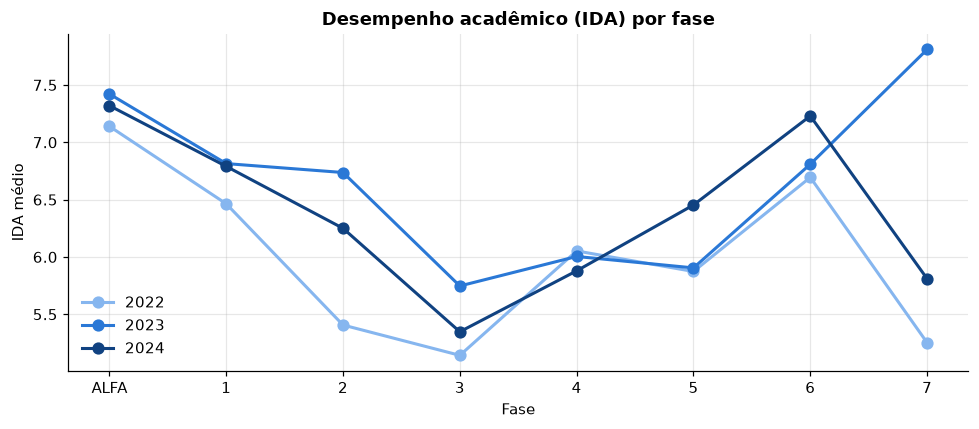

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
for ano, cor in zip([2022, 2023, 2024], ["#86b6ef", "#2a78d6", "#104281"]):
    ax.plot(ida_fase.index, ida_fase[ano], marker="o", markersize=7, linewidth=2, color=cor, label=str(ano))
ax.set_xticks(range(8))
ax.set_xticklabels(["ALFA"] + [str(f) for f in range(1, 8)])
ax.set_xlabel("Fase")
ax.set_ylabel("IDA médio")
ax.set_title("Desempenho acadêmico (IDA) por fase")
ax.legend(frameon=False)
salvar(fig, "q2_ida_por_fase.png")

In [10]:
delta_ida = (painel["ida_t1"] - painel["ida"]).groupby(painel["ano"]).mean()
print("Variação média do IDA do mesmo aluno:")
print(delta_ida.rename(lambda a: f"{a} -> {a + 1}").round(2))

Variação média do IDA do mesmo aluno:
ano
2022 -> 2023    0.12
2023 -> 2024   -0.48
dtype: float64


O IDA não mostra tendência consistente. A média subiu de 6,09 (2022) para 6,66 (2023) e voltou a 6,35 em 2024; no painel, o mesmo aluno ganhou 0,12 ponto de 2022 para 2023 e perdeu 0,48 de 2023 para 2024. A queda de 2024 vem principalmente de Português (de 6,82 para 6,17).

O padrão por fase é o achado mais estável: o desempenho é alto na ALFA (acima de 7), cai até o ponto mais baixo nas fases 2 a 4 (5º ao 9º ano) e se recupera nas fases finais. É nesse trecho intermediário que o reforço acadêmico tem mais espaço.

## 5. Engajamento nas atividades (IEG)

*O grau de engajamento tem relação direta com o desempenho (IDA) e com o ponto de virada (IPV)?*

Usamos correlação de Spearman porque os indicadores têm distribuições assimétricas e concentradas nas notas altas.

In [11]:
for ano, d in alunos.groupby("ano"):
    corr = d[["ieg", "ida", "ipv"]].corr("spearman").loc["ieg", ["ida", "ipv"]]
    print(f"{ano}: IEG x IDA = {corr['ida']:.2f} | IEG x IPV = {corr['ipv']:.2f}")

quartil_ieg = pd.qcut(alunos["ieg"].rank(method="first"), 4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"])
por_quartil = alunos.groupby(quartil_ieg)[["ida", "ipv"]].mean()
por_quartil.round(2)

2022: IEG x IDA = 0.51 | IEG x IPV = 0.54
2023: IEG x IDA = 0.45 | IEG x IPV = 0.49
2024: IEG x IDA = 0.52 | IEG x IPV = 0.55


,ida,ipv
ieg,,
Q1 (menor),4.91,6.69
Q2,6.24,7.44
Q3,6.91,7.85
Q4 (maior),7.44,8.21


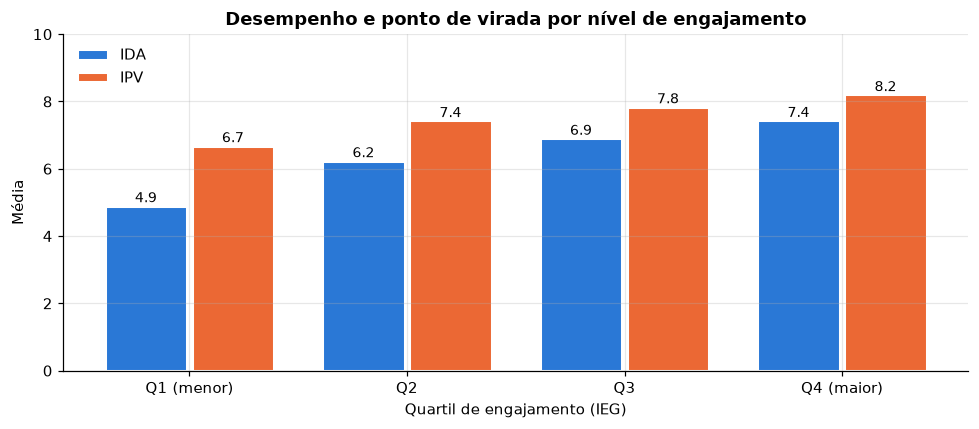

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(4)
ax.bar(x - 0.2, por_quartil["ida"], width=0.38, color=AZUL, label="IDA", edgecolor="white", linewidth=2)
ax.bar(x + 0.2, por_quartil["ipv"], width=0.38, color=LARANJA, label="IPV", edgecolor="white", linewidth=2)
for i in range(4):
    ax.text(i - 0.2, por_quartil["ida"].iloc[i] + 0.1, f"{por_quartil['ida'].iloc[i]:.1f}", ha="center", fontsize=9)
    ax.text(i + 0.2, por_quartil["ipv"].iloc[i] + 0.1, f"{por_quartil['ipv'].iloc[i]:.1f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(por_quartil.index)
ax.set_xlabel("Quartil de engajamento (IEG)")
ax.set_ylabel("Média")
ax.set_ylim(0, 10)
ax.set_title("Desempenho e ponto de virada por nível de engajamento")
ax.legend(frameon=False)
salvar(fig, "q3_ieg_quartis.png")

Sim, e a relação se repete nos três anos: correlação de 0,45 a 0,52 com o IDA e de 0,49 a 0,55 com o IPV. Os alunos no quartil mais engajado têm IDA médio de 7,4, contra 4,9 no quartil menos engajado. A relação é moderada, e correlação não prova que o engajamento cause o desempenho. Ainda assim, dos três indicadores o IEG é o que a associação consegue acompanhar de perto, porque depende de rotina (tarefas, presença) que dá para ver toda semana.

## 6. Autoavaliação (IAA)

*As percepções dos alunos sobre si mesmos são coerentes com o desempenho real (IDA) e o engajamento (IEG)?*

Na limpeza identificamos 190 autoavaliações zeradas em 2023, com forte indício de questionário não respondido. Calculamos as correlações com e sem esses registros para verificar se a conclusão depende deles.

In [13]:
for ano, d in alunos.groupby("ano"):
    com_zeros = d[["iaa", "ida", "ieg"]].corr("spearman").loc["iaa"]
    sem_zeros = d.loc[~d["flag_iaa_zero"], ["iaa", "ida", "ieg"]].corr("spearman").loc["iaa"]
    print(f"{ano}: IAA x IDA = {com_zeros['ida']:.2f} (sem zeros {sem_zeros['ida']:.2f}) | "
          f"IAA x IEG = {com_zeros['ieg']:.2f} (sem zeros {sem_zeros['ieg']:.2f})")

2022: IAA x IDA = 0.18 (sem zeros 0.14) | IAA x IEG = 0.23 (sem zeros 0.16)
2023: IAA x IDA = 0.13 (sem zeros 0.11) | IAA x IEG = 0.19 (sem zeros 0.13)
2024: IAA x IDA = 0.18 (sem zeros 0.15) | IAA x IEG = 0.23 (sem zeros 0.20)


In [14]:
sem_zeros = alunos[~alunos["flag_iaa_zero"]]
gap = sem_zeros["iaa"] - sem_zeros["ida"]
print(f"IAA médio: {sem_zeros['iaa'].mean():.2f} | IDA médio: {sem_zeros['ida'].mean():.2f}")
print(f"Alunos que se avaliam mais de 2 pontos acima do IDA: {(gap > 2).mean():.0%}")
print(f"Alunos que se avaliam mais de 2 pontos abaixo do IDA: {(gap < -2).mean():.0%}")

quartil_ida = pd.qcut(sem_zeros["ida"].rank(method="first"), 4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"])
iaa_ida = sem_zeros.groupby(quartil_ida)[["iaa", "ida"]].mean()
iaa_ida.round(2)

IAA médio: 8.67 | IDA médio: 6.42
Alunos que se avaliam mais de 2 pontos acima do IDA: 51%
Alunos que se avaliam mais de 2 pontos abaixo do IDA: 1%


,iaa,ida
ida,,
Q1 (menor),8.48,3.74
Q2,8.65,5.98
Q3,8.66,7.28
Q4 (maior),8.90,8.68


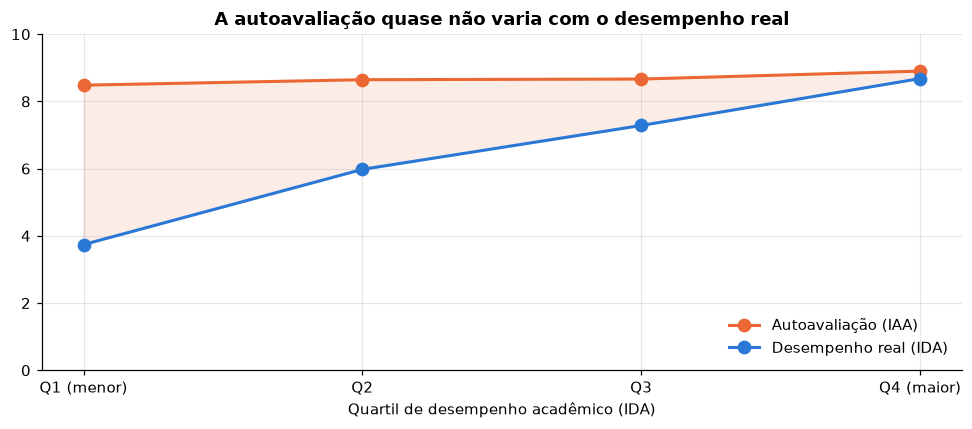

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(4)
ax.plot(x, iaa_ida["iaa"], marker="o", markersize=8, linewidth=2, color=LARANJA, label="Autoavaliação (IAA)")
ax.plot(x, iaa_ida["ida"], marker="o", markersize=8, linewidth=2, color=AZUL, label="Desempenho real (IDA)")
ax.fill_between(x, iaa_ida["ida"], iaa_ida["iaa"], color=LARANJA, alpha=0.12)
ax.set_xticks(x)
ax.set_xticklabels(iaa_ida.index)
ax.set_xlabel("Quartil de desempenho acadêmico (IDA)")
ax.set_ylim(0, 10)
ax.set_title("A autoavaliação quase não varia com o desempenho real")
ax.legend(frameon=False, loc="lower right")
salvar(fig, "q4_iaa_vs_ida.png")

Não são coerentes. A correlação da autoavaliação com o IDA fica entre 0,11 e 0,18 e com o IEG entre 0,13 e 0,23, com ou sem os zeros de 2023, então a conclusão não depende do tratamento dado a eles. Os alunos do quartil de menor desempenho têm IDA médio de 3,7 e se avaliam com 8,5, praticamente a mesma nota dos alunos do quartil mais alto (8,9). Metade dos alunos se avalia mais de 2 pontos acima do próprio IDA.

Nossa leitura é que o IAA hoje mede mais satisfação ou autoestima do que a percepção do próprio desempenho. Como ele pesa 10% no INDE, esse descolamento infla a nota global de alunos com desempenho fraco.

## 7. Aspectos psicossociais (IPS)

*Há padrões psicossociais que antecedem quedas de desempenho acadêmico ou de engajamento?*

"Anteceder" exige olhar o aluno em dois momentos. Usamos o painel e definimos queda como perda de pelo menos 1 ponto no IDA ou no IEG de um ano para o seguinte.

In [16]:
p5 = painel.dropna(subset=["ips", "ida", "ieg", "ida_t1", "ieg_t1"]).copy()
p5["queda_ida"] = (p5["ida_t1"] - p5["ida"]) <= -1
p5["queda_ieg"] = (p5["ieg_t1"] - p5["ieg"]) <= -1
print(f"Taxa de queda no IDA: {p5['queda_ida'].mean():.0%} | no IEG: {p5['queda_ieg'].mean():.0%}")

quartil_ips = pd.qcut(p5["ips"].rank(method="first"), 4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"])
quedas = p5.groupby(quartil_ips)[["queda_ida", "queda_ieg"]].mean()
(quedas * 100).round(0)

Taxa de queda no IDA: 31% | no IEG: 23%


,queda_ida,queda_ieg
ips,,
Q1 (menor),36.0,33.0
Q2,32.0,24.0
Q3,23.0,12.0
Q4 (maior),32.0,25.0


In [17]:
# Quem já está alto tende a cair (regressão à média). Controlamos pelo nível atual para isolar o efeito do IPS.
for alvo, nivel in [("queda_ida", "ida"), ("queda_ieg", "ieg")]:
    X = StandardScaler().fit_transform(p5[[nivel, "ips"]])
    modelo = LogisticRegression().fit(X, p5[alvo])
    print(f"{alvo}: coeficiente padronizado do IPS = {modelo.coef_[0][1]:.2f} (controlando por {nivel.upper()} atual)")

queda_ida: coeficiente padronizado do IPS = -0.23 (controlando por IDA atual)
queda_ieg: coeficiente padronizado do IPS = -0.32 (controlando por IEG atual)


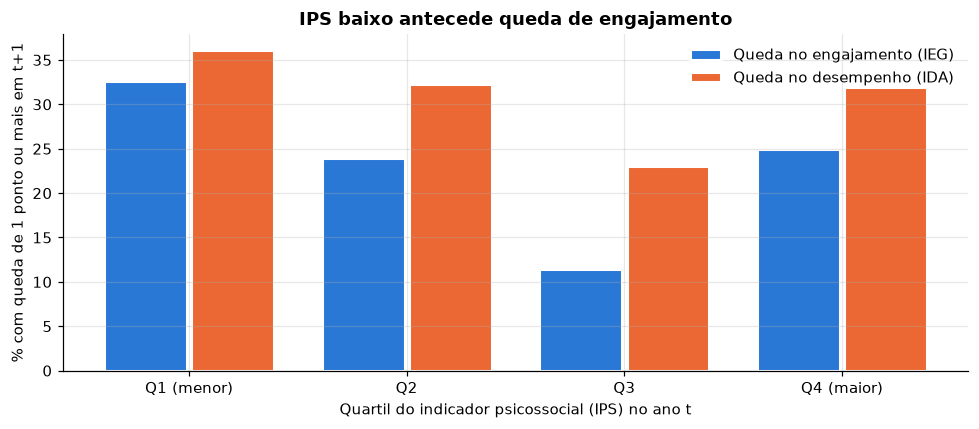

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(4)
ax.bar(x - 0.2, quedas["queda_ieg"] * 100, width=0.38, color=AZUL, label="Queda no engajamento (IEG)", edgecolor="white", linewidth=2)
ax.bar(x + 0.2, quedas["queda_ida"] * 100, width=0.38, color=LARANJA, label="Queda no desempenho (IDA)", edgecolor="white", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(quedas.index)
ax.set_xlabel("Quartil do indicador psicossocial (IPS) no ano t")
ax.set_ylabel("% com queda de 1 ponto ou mais em t+1")
ax.set_title("IPS baixo antecede queda de engajamento")
ax.legend(frameon=False)
salvar(fig, "q5_ips_quedas.png")

In [19]:
print("Distribuição do IPS por ano:")
alunos.groupby("ano")["ips"].describe()[["mean", "25%", "50%", "75%"]].round(2)

Distribuição do IPS por ano:


,mean,25%,50%,75%
ano,,,,
2022,6.90,6.30,7.50,7.50
2023,5.12,2.52,5.00,7.52
2024,6.83,6.26,7.51,7.51


Há um sinal, mais forte para engajamento do que para desempenho. Entre os alunos com IPS no quartil mais baixo, 33% tiveram queda no IEG no ano seguinte, contra 12% no terceiro quartil. Controlando pelo nível atual de cada indicador, um IPS mais baixo aumenta a chance de queda no IEG (coeficiente −0,32) e, em menor grau, no IDA (−0,23). O sinal é modesto e o IPS sozinho não separa bem quem vai cair. Serve, porém, como alerta precoce, porque a dificuldade emocional aparece antes da queda de engajamento.

Uma ressalva de medição: a distribuição do IPS muda muito entre os anos (mediana de 7,5 em 2022 e 5,0 em 2023). Isso sugere mudança no instrumento ou nos avaliadores, e o IPS não deve ser comparado em nível absoluto entre anos.

## 8. Aspectos psicopedagógicos (IPP)

*As avaliações psicopedagógicas confirmam ou contradizem a defasagem identificada pelo IAN?*

O IPP só existe em 2023 e 2024.

In [20]:
c6 = alunos[alunos["ano"] > 2022].dropna(subset=["ipp"])
print(c6.groupby("nivel_defasagem")["ipp"].agg(["mean", "median", "size"]).round(2))
print(f"\nCorrelação de Spearman IPP x defasagem: {c6[['ipp', 'defasagem']].corr('spearman').iloc[0, 1]:.2f}")

quartil_ipp = pd.qcut(c6["ipp"].rank(method="first"), 4, labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"])
(pd.crosstab(quartil_ipp, c6["nivel_defasagem"], normalize="index") * 100).round(0)

                 mean  median  size
nivel_defasagem                    
Em fase          7.68    7.71   908
Moderada         7.46    7.50  1067
Severa           7.01    7.50    17

Correlação de Spearman IPP x defasagem: 0.17


nivel_defasagem,Em fase,Moderada,Severa
ipp,,,
Q1 (menor),36.0,62.0,2.0
Q2,42.0,58.0,0.0
Q3,49.0,50.0,1.0
Q4 (maior),55.0,45.0,0.0


O IPP confirma a direção do IAN, mas fracamente. O IPP médio cai de 7,68 entre os alunos em fase para 7,46 na defasagem moderada e 7,01 na severa, e no quartil mais alto de IPP 55% dos alunos estão em fase, contra 36% no mais baixo. A correlação, porém, é de apenas 0,17.

Os dois indicadores medem coisas diferentes. O IAN é administrativo (fase atual contra fase esperada para a idade), enquanto o IPP captura a avaliação do processo de aprendizagem. Um aluno pode estar na fase certa e ainda assim ter dificuldades psicopedagógicas, e o IPP ajuda a encontrar esses casos, que o IAN não enxerga.

## 9. Ponto de virada (IPV)

*Quais comportamentos (acadêmicos, emocionais ou de engajamento) mais influenciam o IPV ao longo do tempo?*

Olhamos duas coisas: a relação no mesmo ano e o que, no ano t, ajuda a explicar o IPV do ano seguinte.

In [21]:
for ano, d in alunos.groupby("ano"):
    corr = d[["ipv", "ida", "ieg", "ipp", "iaa", "ips"]].corr("spearman").loc["ipv"].drop("ipv")
    print(ano, corr.round(2).to_dict())

2022 {'ida': 0.62, 'ieg': 0.54, 'ipp': nan, 'iaa': 0.24, 'ips': 0.19}
2023 {'ida': 0.55, 'ieg': 0.49, 'ipp': 0.51, 'iaa': 0.16, 'ips': 0.07}
2024 {'ida': 0.55, 'ieg': 0.55, 'ipp': 0.71, 'iaa': 0.16, 'ips': 0.04}


In [22]:
X_COLS = ["ida", "ieg", "iaa", "ips", "ipv"]
d7 = painel.dropna(subset=X_COLS + ["ipv_t1"])
X = StandardScaler().fit_transform(d7[X_COLS])
reg = LinearRegression().fit(X, d7["ipv_t1"])

coef_ipv = pd.Series(reg.coef_, index=[c.upper() + " (t)" for c in X_COLS]).sort_values()
print(f"R² = {reg.score(X, d7['ipv_t1']):.2f}")
coef_ipv.round(3)

R² = 0.23


IEG (t)    0.073
IAA (t)    0.159
IPV (t)    0.200
IDA (t)    0.210
IPS (t)    0.228
dtype: float64

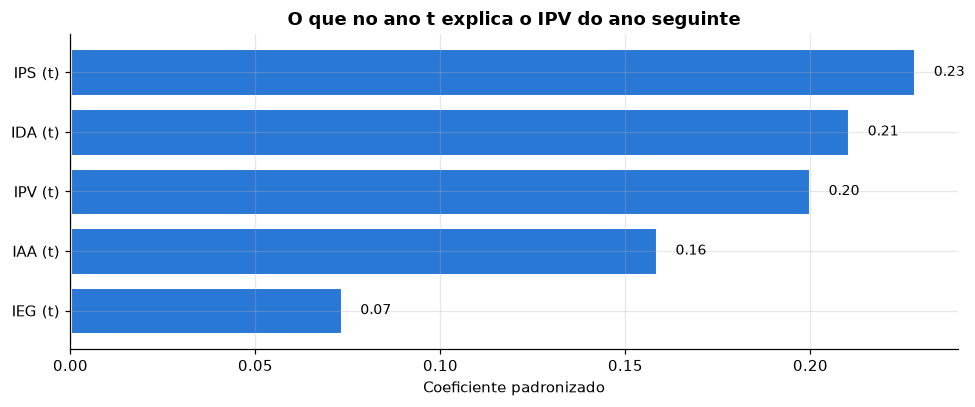

In [23]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(coef_ipv.index, coef_ipv.values, color=AZUL, edgecolor="white", linewidth=2)
for i, v in enumerate(coef_ipv.values):
    ax.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=9)
ax.set_xlabel("Coeficiente padronizado")
ax.set_title("O que no ano t explica o IPV do ano seguinte")
salvar(fig, "q7_ipv_longitudinal.png")

In [24]:
print("Médias de 2022 por atingimento do ponto de virada:")
alunos[alunos["ano"] == 2022].groupby("atingiu_pv")[["ida", "ieg", "iaa", "ips", "ipv"]].mean().round(2)

Médias de 2022 por atingimento do ponto de virada:


,ida,ieg,iaa,ips,ipv
atingiu_pv,,,,,
0.0,5.82,7.72,8.18,6.84,7.01
1.0,7.87,9.01,8.87,7.32,8.86


No mesmo ano, o IPV anda junto com o desempenho acadêmico (correlação de 0,55 a 0,62 com o IDA), com o engajamento (0,49 a 0,55) e, cada vez mais, com o psicopedagógico (IPP: 0,51 em 2023 e 0,71 em 2024). O psicossocial quase não aparece (0,04 a 0,19).

Ao longo do tempo o quadro muda. Para explicar o IPV do ano seguinte, os fatores mais relevantes são o IPS do ano anterior (0,23), o IDA (0,21) e o próprio IPV (0,20); o engajamento perde força (0,07). O aspecto emocional não aparece no retrato do ano, mas antecede o ponto de virada, o que é coerente com o achado da pergunta 5. O R² de 0,23 mostra que boa parte do IPV futuro depende de fatores que a base não captura.

Em 2022, único ano com a flag de ponto de virada preenchida, quem atingiu o PV tinha IDA 2 pontos acima (7,9 contra 5,8) e IEG 1,3 ponto acima dos demais.

## 10. Multidimensionalidade dos indicadores

*Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?*

Primeiro verificamos como o INDE é composto, regredindo-o nos sete indicadores:

In [25]:
componentes = ["ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv"]
for ano in [2023, 2024]:
    d = alunos[alunos["ano"] == ano].dropna(subset=componentes + ["inde"])
    reg = LinearRegression().fit(d[componentes], d["inde"])
    pesos = dict(zip([c.upper() for c in componentes], reg.coef_.round(3)))
    print(f"{ano}: R² = {reg.score(d[componentes], d['inde']):.4f} | pesos = {pesos}")

2023: R² = 1.0000 | pesos = {'IAN': np.float64(0.1), 'IDA': np.float64(0.2), 'IEG': np.float64(0.2), 'IAA': np.float64(0.1), 'IPS': np.float64(0.1), 'IPP': np.float64(0.1), 'IPV': np.float64(0.2)}
2024: R² = 1.0000 | pesos = {'IAN': np.float64(0.1), 'IDA': np.float64(0.2), 'IEG': np.float64(0.2), 'IAA': np.float64(0.1), 'IPS': np.float64(0.1), 'IPP': np.float64(0.1), 'IPV': np.float64(0.2)}


O R² igual a 1 confirma que o INDE é uma média ponderada fixa: INDE = 0,1·IAN + 0,2·IDA + 0,2·IEG + 0,1·IAA + 0,1·IPS + 0,1·IPP + 0,2·IPV. Com os pesos conhecidos, o que interessa é saber qual indicador faz o INDE variar entre os alunos e onde há mais espaço de ganho.

In [26]:
PESOS = {"ian": .1, "ida": .2, "ieg": .2, "iaa": .1, "ips": .1, "ipp": .1, "ipv": .2}
c8 = alunos[alunos["ano"] > 2022].dropna(subset=componentes + ["inde"]).copy()

# Participação de cada indicador na variância do INDE: peso x cov(indicador, INDE) / var(INDE)
participacao = pd.Series({k.upper(): w * np.cov(c8[k], c8["inde"])[0, 1] / c8["inde"].var() for k, w in PESOS.items()})
# Ganho potencial: quanto o INDE médio subiria se o indicador chegasse a 10
potencial = pd.Series({k.upper(): w * (10 - c8[k].mean()) for k, w in PESOS.items()})

pd.DataFrame({"peso": [PESOS[k.lower()] for k in participacao.index],
              "media": [c8[k.lower()].mean() for k in participacao.index],
              "participacao_variancia": participacao,
              "ganho_potencial": potencial}).sort_values("participacao_variancia", ascending=False).round(2)

,peso,media,participacao_variancia,ganho_potencial
IDA,0.2,6.50,0.30,0.70
IEG,0.2,8.38,0.22,0.32
IPV,0.2,7.67,0.15,0.47
IAA,0.1,7.78,0.12,0.22
IAN,0.1,7.26,0.10,0.27
IPP,0.1,7.56,0.05,0.24
IPS,0.1,6.03,0.05,0.40


In [27]:
alto = lambda s: s >= s.median()
c8["combinacao"] = np.select(
    [alto(c8["ida"]) & alto(c8["ieg"]) & alto(c8["ipp"]) & alto(c8["ips"]),
     alto(c8["ida"]) & alto(c8["ieg"]),
     alto(c8["ida"]) | alto(c8["ieg"])],
    ["IDA + IEG + IPP + IPS altos", "IDA + IEG altos", "Só IDA ou só IEG alto"],
    default="IDA e IEG baixos",
)
combos = (c8.groupby("combinacao")
            .agg(alunos=("inde", "size"), inde_medio=("inde", "mean"),
                 pct_topazio=("pedra", lambda s: (s == "Topázio").mean() * 100))
            .sort_values("inde_medio", ascending=False))
combos.round(1)

,alunos,inde_medio,pct_topazio
combinacao,,,
IDA + IEG + IPP + IPS altos,307,8.4,81.8
IDA + IEG altos,368,8.0,51.4
Só IDA ou só IEG alto,644,7.5,17.5
IDA e IEG baixos,666,6.5,0.8


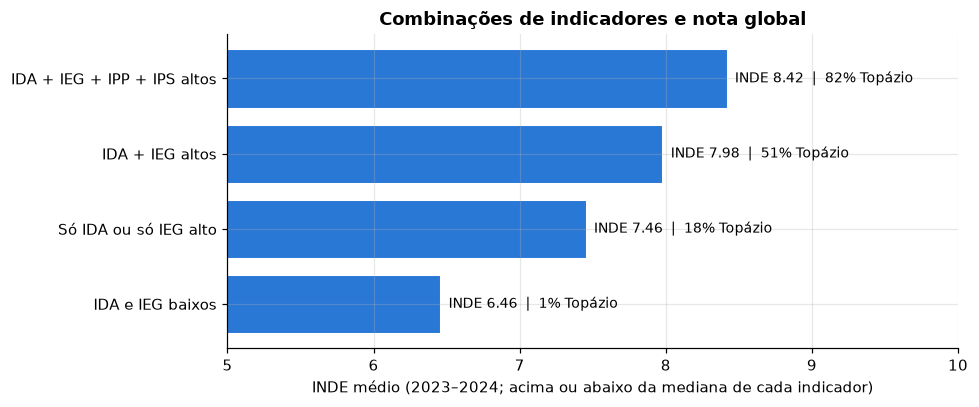

In [28]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(combos.index[::-1], combos["inde_medio"][::-1], color=AZUL, edgecolor="white", linewidth=2)
for i, (v, t) in enumerate(zip(combos["inde_medio"][::-1], combos["pct_topazio"][::-1])):
    ax.text(v + 0.05, i, f"INDE {v:.2f}  |  {t:.0f}% Topázio", va="center", fontsize=9)
ax.set_xlim(5, 10)
ax.set_xlabel("INDE médio (2023–2024; acima ou abaixo da mediana de cada indicador)")
ax.set_title("Combinações de indicadores e nota global")
salvar(fig, "q8_combinacoes_inde.png")

O IDA é o indicador que mais diferencia os alunos no INDE: responde por 30% da variação da nota global, seguido pelo IEG (22%) e pelo IPV (15%). O IPS e o IPP, embora façam parte da pergunta, respondem por apenas 5% cada, porque pesam 0,1 e variam pouco em relação ao INDE.

O IDA também tem o maior espaço de ganho: é o indicador de peso 0,2 com a menor média (6,5), e levá-lo a 10 somaria 0,70 ponto ao INDE médio. A combinação que mais eleva a nota é ter os quatro indicadores acima da mediana (INDE médio de 8,42 e 82% de Topázio). Só IDA e IEG altos já levam a 7,98, enquanto IDA e IEG baixos ficam em 6,46, com apenas 1% de Topázio. Desempenho com engajamento é a base da nota.

## 11. Efetividade do programa

*Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio)?*

Comparamos o retrato anual com o painel dos mesmos alunos, porque o retrato é afetado pela entrada e pela saída de alunos.

In [29]:
print("Retrato anual (média de todos os alunos):")
print(alunos.groupby("ano")[INDICADORES].mean().round(2))
print()
print("Painel (variação média do mesmo aluno de t para t+1):")
variacao = pd.DataFrame({k.upper(): (painel[k + "_t1"] - painel[k]).groupby(painel["ano"]).mean() for k in INDICADORES})
variacao.rename(lambda a: f"{a} -> {a + 1}").round(2)

Retrato anual (média de todos os alunos):
      inde   ida   ieg   iaa   ips   ipp   ipv
ano                                           
2022  7.04  6.09  7.89  8.27  6.90   NaN  7.25
2023  7.34  6.66  8.70  6.90  5.12  7.56  8.03
2024  7.40  6.35  8.09  8.54  6.83  7.55  7.35

Painel (variação média do mesmo aluno de t para t+1):


,INDE,IDA,IEG,IAA,IPS,IPP,IPV
ano,,,,,,,
2022 -> 2023,-0.02,0.12,0.23,-1.79,-1.92,NaN,0.55
2023 -> 2024,-0.05,-0.48,-0.80,1.57,1.61,-0.09,-0.79


In [30]:
transicao = pd.crosstab(painel["pedra"], painel["pedra_t1"], normalize="index")
transicao = transicao.reindex(index=ORDEM_PEDRA, columns=ORDEM_PEDRA)

nivel_pedra = {p: i for i, p in enumerate(ORDEM_PEDRA)}
com_pedra = painel.dropna(subset=["pedra", "pedra_t1"])
mudanca = com_pedra["pedra_t1"].map(nivel_pedra).astype(int) - com_pedra["pedra"].map(nivel_pedra).astype(int)
print(f"Sobem de pedra: {(mudanca > 0).mean():.0%} | mantêm: {(mudanca == 0).mean():.0%} | caem: {(mudanca < 0).mean():.0%}")
(transicao * 100).round(0)

Sobem de pedra: 24% | mantêm: 51% | caem: 25%


pedra_t1,Quartzo,Ágata,Ametista,Topázio
pedra,,,,
Quartzo,41.0,48.0,11.0,0.0
Ágata,18.0,47.0,29.0,6.0
Ametista,5.0,21.0,48.0,26.0
Topázio,1.0,5.0,32.0,63.0


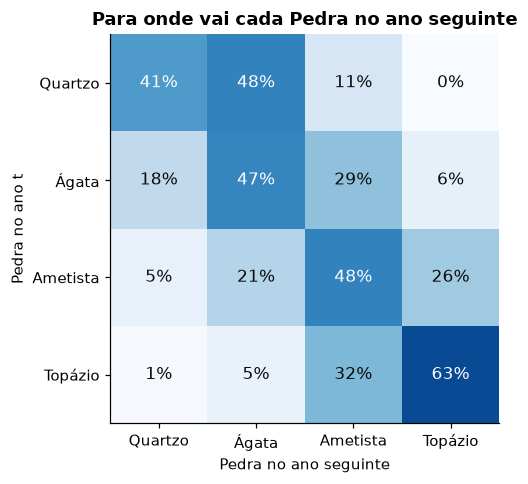

In [31]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
im = ax.imshow(transicao.values * 100, cmap="Blues", vmin=0, vmax=70)
for i in range(4):
    for j in range(4):
        v = transicao.values[i, j] * 100
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", color="white" if v > 40 else "#0b0b0b", fontsize=11)
ax.set_xticks(range(4))
ax.set_xticklabels(ORDEM_PEDRA)
ax.set_yticks(range(4))
ax.set_yticklabels(ORDEM_PEDRA)
ax.set_xlabel("Pedra no ano seguinte")
ax.set_ylabel("Pedra no ano t")
ax.set_title("Para onde vai cada Pedra no ano seguinte")
ax.grid(False)
salvar(fig, "q10_transicao_pedra.png")

In [32]:
print("Quem sai do programa x quem fica (valores no ano t):")
for t in [2022, 2023]:
    d = alunos[alunos["ano"] == t].copy()
    d["situacao"] = np.where(d["ra"].isin(df.loc[df["ano"] == t + 1, "ra"]), "ficou", "saiu")
    print(f"\n{t} -> {t + 1}")
    print(d.groupby("situacao")[["inde", "ida", "ieg", "ipv"]].agg("mean").round(2).assign(alunos=d["situacao"].value_counts()))

Quem sai do programa x quem fica (valores no ano t):

2022 -> 2023
          inde   ida   ieg   ipv  alunos
situacao                                
ficou     7.26  6.47  8.30  7.45     600
saiu      6.51  5.23  6.95  6.79     260

2023 -> 2024
          inde   ida   ieg   ipv  alunos
situacao                                
ficou     7.46  6.83  8.86  8.12     706
saiu      7.02  6.20  8.23  7.78     245


A resposta depende do indicador. A defasagem melhora de forma consistente: entre os mesmos alunos, a proporção em fase vai de 34% para 63% em dois anos (pergunta 1).

Com o INDE é diferente. O retrato anual sugere melhora (de 7,04 para 7,40), mas no painel o mesmo aluno fica praticamente estável (−0,02 e −0,05 ponto). Parte da alta anual vem da saída de alunos com indicadores mais baixos: em 2022, quem saiu tinha INDE médio de 6,51, contra 7,26 de quem ficou.

Nas pedras, a matriz de transição mostra movimento nos dois sentidos. 59% dos Quartzo sobem de pedra, mas 37% dos Topázio caem. No total, 24% dos alunos sobem e 25% caem, padrão típico de regressão à média.

Os dados confirmam o impacto do programa na adequação de nível, que é seu objetivo mais direto, mas não mostram melhora individual consistente nos demais indicadores. Sem grupo de controle, também não dá para atribuir a melhora da defasagem ao programa de forma causal. As oscilações fortes de IAA e IPS entre anos (queda de cerca de 1,8 ponto e depois alta equivalente) parecem vir de mudanças na forma de medir, mais do que de mudanças nos alunos.

## 12. Insights adicionais

### 12.1 Retenção de fase

A defasagem piora quando o aluno não avança de fase enquanto a fase esperada para a idade avança. Olhamos quem permanece na mesma fase de um ano para o outro:

In [33]:
retencao = painel.assign(retido=painel["fase_t1"] == painel["fase"])
print(f"Alunos que não avançaram de fase: {retencao['retido'].mean():.0%}")
print()
print(retencao.groupby("nivel_defasagem")["retido"].mean().round(2).rename("taxa de retenção"))
por_fase = retencao.groupby("fase")["retido"].agg(["mean", "size"])
por_fase.round(2)

Alunos que não avançaram de fase: 30%

nivel_defasagem
Em fase     0.43
Moderada    0.23
Severa      0.00
Name: taxa de retenção, dtype: float64


,mean,size
fase,,
0,0.48,322
1,0.28,280
2,0.17,265
3,0.28,179
4,0.13,117
5,0.39,79
6,0.11,19
7,1.00,12


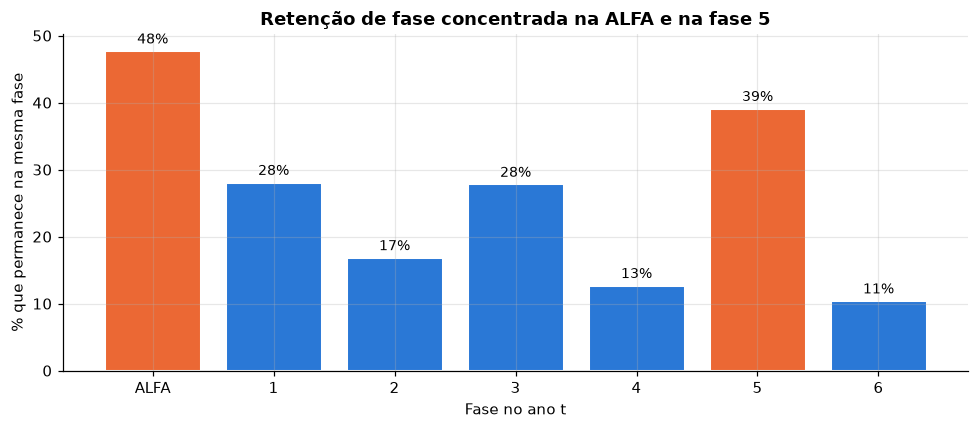

In [34]:
fig, ax = plt.subplots(figsize=(9, 4))
cores = [LARANJA if f in (0, 5) else AZUL for f in por_fase.index[:7]]
ax.bar([("ALFA" if f == 0 else str(f)) for f in por_fase.index[:7]], por_fase["mean"].iloc[:7] * 100,
       color=cores, edgecolor="white", linewidth=2)
for i, v in enumerate(por_fase["mean"].iloc[:7] * 100):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
ax.set_xlabel("Fase no ano t")
ax.set_ylabel("% que permanece na mesma fase")
ax.set_title("Retenção de fase concentrada na ALFA e na fase 5")
salvar(fig, "q11_retencao_fase.png")

Três em cada dez alunos não avançam de fase de um ano para o outro, e a retenção se concentra na ALFA (48%) e na fase 5 (39%). A fase 7 foi omitida do gráfico: tem apenas 12 alunos, todos retidos por ser a última fase do ciclo.

A retenção é maior entre os alunos em fase (43%) do que entre os já defasados (23%). O risco de entrar em defasagem está, portanto, nos alunos que hoje parecem estar bem, e é esse o público que o modelo preditivo do notebook 03 procura antecipar.

### 12.2 Tempo de programa, tipo de escola e gênero

In [35]:
print("INDE médio por anos no programa:")
print(alunos.assign(anos=alunos["ano"] - alunos["ano_ingresso"]).groupby("anos")["inde"].agg(["mean", "size"]).round(2).T)
print()
print(alunos.groupby("instituicao")[["inde", "ida"]].mean().round(2).assign(alunos=alunos["instituicao"].value_counts()))
print()
print(alunos.groupby("genero")[["inde", "ida", "ieg", "iaa", "ips"]].mean().round(2))

INDE médio por anos no programa:
anos        0       1       2       3       4       5      6      7     8
mean     7.33    7.31    7.35    7.11    7.12    7.03   7.16   7.29   7.4
size  1106.00  645.00  350.00  258.00  190.00  163.00  94.00  41.00  18.0

                             inde   ida  alunos
instituicao                                    
Concluiu EM / Universitário  7.33  7.34      11
Outros                       7.32  6.48       3
Privada                      7.73  7.00     378
Pública                      7.20  6.28    2473

           inde   ida   ieg   iaa   ips
genero                                 
Feminino   7.34  6.40  8.32  7.90  6.19
Masculino  7.19  6.35  8.13  7.93  6.40


O tempo de programa não muda o INDE médio, que fica entre 7,0 e 7,4 tanto no primeiro quanto no oitavo ano de programa. Não há efeito cumulativo visível na nota global, o que reforça a leitura da pergunta 10.

Os bolsistas em escola privada têm INDE de 7,73 e IDA de 7,00, contra 7,20 e 6,28 na escola pública. Pode ser efeito da escola ou do critério de seleção para a bolsa, que tende a escolher os alunos de melhor desempenho; a base não permite separar as duas explicações.

Entre meninas e meninos as diferenças são pequenas (INDE de 7,34 e 7,19) e não sugerem ação específica.

## Conclusão

### Respostas às perguntas

1. IAN: metade dos alunos ainda tem defasagem moderada, mas a proporção em fase subiu de 30% para 49% entre 2022 e 2024, e entre os mesmos alunos foi de 34% para 63%. A defasagem severa praticamente zerou.
2. IDA: está estagnado, com alta em 2023 e queda em 2024 puxada por Português. O desempenho é mais baixo nas fases intermediárias (2 a 4).
3. IEG: tem relação moderada e estável com o IDA (ρ ≈ 0,5) e com o IPV (ρ ≈ 0,5).
4. IAA: não é coerente com o desempenho (ρ < 0,2). Os alunos se avaliam alto independentemente do IDA.
5. IPS: IPS baixo antecede queda de engajamento no ano seguinte. O sinal é modesto, mas consistente.
6. IPP: confirma a direção do IAN, mas fracamente (ρ = 0,17), e mede uma dimensão diferente.
7. IPV: no mesmo ano acompanha IDA, IEG e IPP; ao longo do tempo, é antecipado pelo IPS e pelo IDA do ano anterior.
8. INDE: IDA e IEG altos são a base da nota. Os quatro indicadores acima da mediana levam a INDE de 8,4 e 82% de Topázio, e o IDA é o maior espaço de ganho.
9. Risco (notebook 03): o modelo identifica 3 em cada 4 alunos que vão entrar em defasagem no ano seguinte, sinalizando cerca de 1 em cada 4 alunos para acompanhamento.
10. Efetividade: o impacto aparece na adequação de nível. INDE e Pedras não mostram melhora individual consistente, e a média anual é inflada pela saída de alunos com indicadores mais baixos.
11. Insights: a retenção de fase atinge 30% dos alunos ao ano, concentra-se na ALFA e na fase 5 e é maior justamente entre os alunos que estão em fase.

### Recomendações para a Passos Mágicos

- Usar o modelo no início do ano letivo para priorizar o acompanhamento dos alunos em fase com maior risco de retenção, principalmente na ALFA e na fase 5.
- Tratar o IPS como alerta precoce de queda de engajamento, acionando o acompanhamento psicológico antes que a queda apareça no IEG.
- Revisar o instrumento de autoavaliação, porque o IAA não discrimina desempenho e infla o INDE de alunos com IDA baixo.
- Padronizar a medição de IPS e IAA entre anos, para que as séries históricas sejam comparáveis.
- Registrar o motivo de saída dos alunos. Cerca de 30% saem a cada ano, com indicadores mais baixos, e sem esse registro não é possível medir a efetividade real do programa.
- Concentrar o reforço acadêmico nas fases 2 a 4 e em Português, onde está a maior alavanca de INDE.